In [1]:
import xarray as xr
import sys
sys.path.append('/home/548/cd3022/repos/solar-nowcast/modules')
import sat_preprocess
from datetime import datetime

In [ ]:
files = sat_preprocess.get_files(channel, start, end, step_minutes=10)

sat_preprocess.get_ancil(files[0])

In [2]:
start = datetime(2024, 1, 1)
end   = datetime(2024, 1, 2)
lat_min, lat_max, lon_min, lon_max = 32, 33, 151, 152
channel='B06'

ds = sat_preprocess.read_himawari_channel('B06', start, end, lat_min, lat_max, lon_min, lon_max)

/home/548/cd3022/repos/solar-nowcast/modules/sat_preprocess.py:111: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  return xr.open_mfdataset(files, preprocess=preprocess)


In [3]:
ds

<xarray.Dataset> Size: 1MB
Dimensions:                       (time: 142, y: 44, x: 51)
Coordinates:
  * time                          (time) datetime64[ns] 1kB 2024-01-01 ... 20...
  * y                             (y) float64 352B 3.339e+06 ... 3.253e+06
  * x                             (x) float64 408B 9.29e+05 ... 1.029e+06
Data variables:
    channel_0006_scaled_radiance  (time, y, x) float32 1MB dask.array<chunksize=(1, 20, 51), meta=np.ndarray>
    geostationary                 (time) float32 568B 9.969e+36 ... 9.969e+36
    scan_line_time                (time, y) datetime64[ns] 50kB dask.array<chunksize=(1, 20), meta=np.ndarray>
Attributes: (12/60)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    acknowledgment:                  See disclaimer
    cdm_data_type:                   grid
    comment:                         AGLS observations geometry product
    contributor_name:                Commonwealth of Australia, Bureau of Met...
    ...                              ...
    time_coverage_start:             20240101T000021Z
    wmo_platform_name:               Himawari-9
    wmo_satellite_number:            174
    history:                         Tue Mar  5 04:21:03 2024: ncatted -O -a ...
    NCO:                             netCDF Operators version 4.7.7 (Homepage...
    product_version:                 1.0

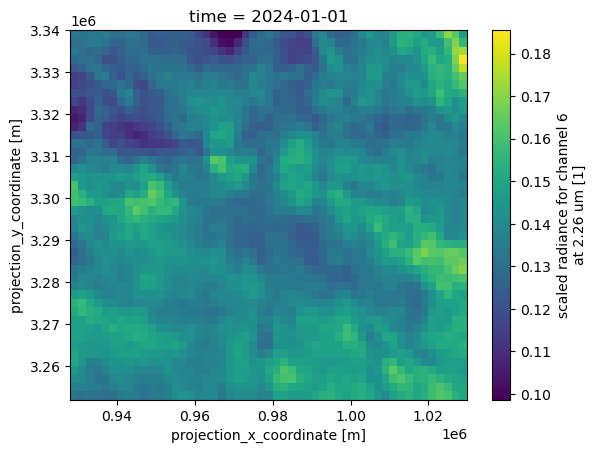

In [4]:
ds.isel(time=0).channel_0006_scaled_radiance.plot()